# 04 - Explainable AI: SHAP & Integrated Gradients (ĐA LỚP)

Giải thích dùng mô hình **đa lớp** đã train ở NB02. SHAP GradientExplainer (global) +
Integrated Gradients (local, theo lớp dự đoán). Thay Grad-CAM bằng IG vì IG phù hợp MLP/tabular.

In [1]:
# === Thiết lập môi trường ỔN ĐỊNH (tránh lỗi Drive 'Transport endpoint is not connected') ===
# Làm việc trên Ổ CỨNG LOCAL /content (nhanh + ổn định); chỉ ĐỒNG BỘ kết quả về Drive ở cuối.
import os, time, shutil
from contextlib import contextmanager

DRIVE = '/content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final'
PROJECT_PATH = '/content/cdmlp'
NEED_RAW = False   # True chi voi notebook 08 (cross-dataset can data/raw)
ON_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    ON_COLAB = True
except Exception:
    here = os.getcwd()
    while here != os.path.dirname(here) and not os.path.isdir(os.path.join(here, 'notebooks')):
        here = os.path.dirname(here)
    DRIVE = here; PROJECT_PATH = here

def _pull(rel):
    s = os.path.join(DRIVE, rel); d = os.path.join(PROJECT_PATH, rel)
    if os.path.isdir(s): shutil.copytree(s, d, dirs_exist_ok=True)
    elif os.path.isfile(s):
        os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy2(s, d)

if ON_COLAB:
    os.makedirs(PROJECT_PATH, exist_ok=True)
    for rel in ['scripts','src','models','results','data/colab_processed','data/ton_iot.csv']:
        try: _pull(rel)
        except Exception as e: print('  (bo qua)', rel, e)
    if NEED_RAW:
        print('  Dang keo data/raw (~550MB, 1-3 phut)...')
        try: _pull('data/raw')
        except Exception as e: print('  (bo qua) data/raw', e)

os.makedirs(PROJECT_PATH, exist_ok=True); os.chdir(PROJECT_PATH)
try:
    get_ipython().run_line_magic('cd', PROJECT_PATH)  # dam bao '!python ...' cung chay o local dir
except Exception:
    pass
for d in ('data/colab_processed','results','results/xai','models'):
    os.makedirs(d, exist_ok=True)
print('PROJECT_PATH (local) =', PROJECT_PATH, '| ON_COLAB =', ON_COLAB)

def find_data_csv():
    for c in ['data/ton_iot.csv','data/raw/ton_iot.csv','ton_iot.csv']:
        if os.path.exists(c): return c
    raise FileNotFoundError('Khong tim thay ton_iot.csv (Drive: data/ton_iot.csv).')

@contextmanager
def step(name):
    t0=time.time(); print(f'\n[START] {name}', flush=True)
    try: yield
    finally: print(f'[DONE] {name} - {time.time()-t0:.1f}s', flush=True)

def sync_to_drive():
    if not ON_COLAB:
        print('[local] bo qua sync Drive'); return
    for rel in ['data/colab_processed','models','results']:
        s = os.path.join(PROJECT_PATH, rel)
        if os.path.exists(s): shutil.copytree(s, os.path.join(DRIVE, rel), dirs_exist_ok=True)
    print('[OK] Da dong bo ket qua ve Drive:', DRIVE)


Mounted at /content/drive
/content
PROJECT_PATH (local) = /content/cdmlp | ON_COLAB = True


In [2]:
!pip -q install pandas numpy tensorflow shap pyarrow matplotlib


[START] Load model + samples


[DONE] Load model + samples - 2.7s
[INFO] background (100, 30) | samples (50, 30) | classes 10

[START] SHAP GradientExplainer (da lop)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(50, 30))']
  warnings.warn(msg)


[DONE] SHAP GradientExplainer (da lop) - 6.3s


/tmp/ipykernel_18848/1002008655.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mean_abs, pd.DataFrame(samples, columns=features), show=False)


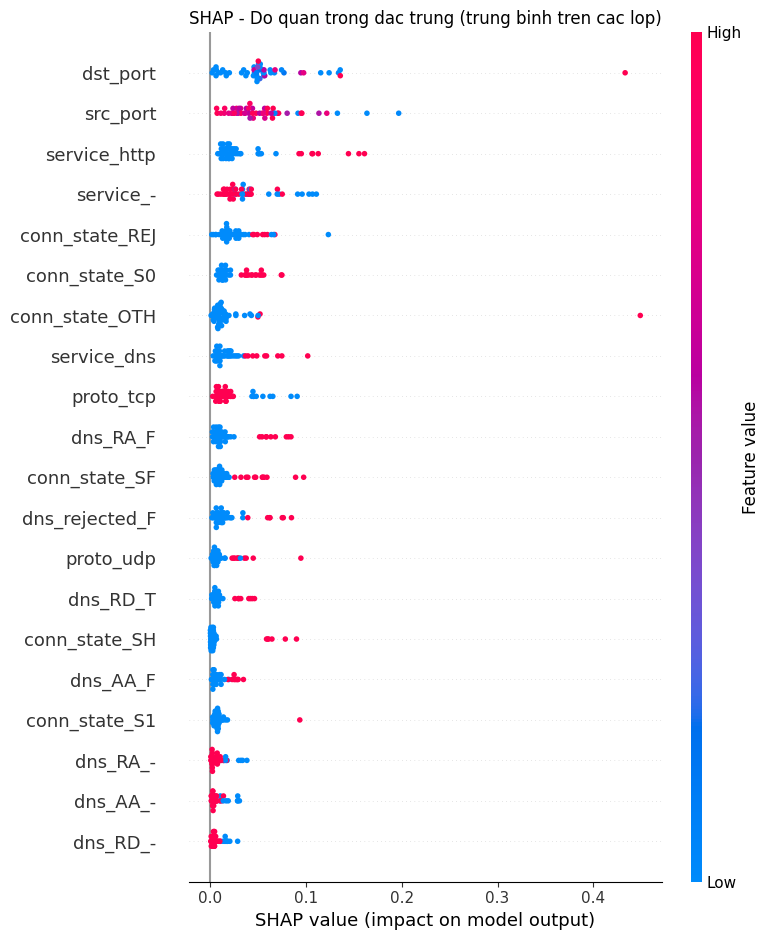


[START] Integrated Gradients (local, theo lop du doan)
[DONE] Integrated Gradients (local, theo lop du doan) - 1.1s
[INFO] Giai thich mau #0 -> lop du doan = backdoor


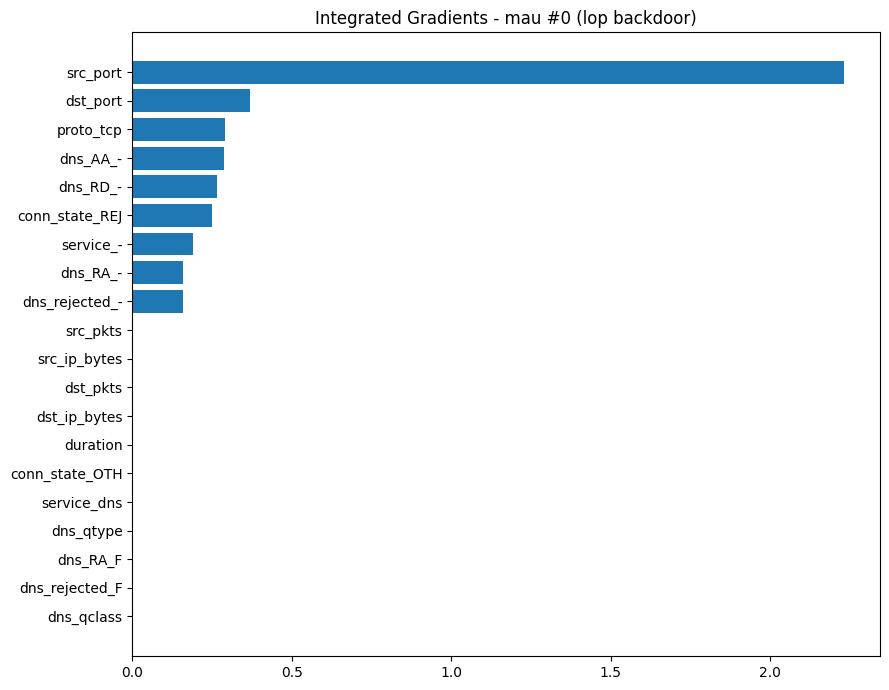

[OK] Da luu SHAP + IG (da lop).


In [3]:
import os, json, numpy as np, pandas as pd, tensorflow as tf, matplotlib.pyplot as plt, shap
from tensorflow.keras.models import load_model
OUT='data/colab_processed'; RESULTS='results/xai'; MODELS='models'; os.makedirs(RESULTS, exist_ok=True)
model_path=f'{MODELS}/colab_cyberdetect_mlp.h5'; assert os.path.exists(model_path), 'Chay NB02 truoc.'
meta=json.load(open(f'{MODELS}/colab_preprocessing_metadata.json', encoding='utf-8'))
features=meta['top_features']; CLASS_NAMES=meta['class_names']
X_train=pd.read_parquet(f'{OUT}/X_train_top30.parquet'); X_test=pd.read_parquet(f'{OUT}/X_test_top30.parquet')
with step('Load model + samples'):
    model=load_model(model_path); background=X_train.values[:100]; samples=X_test.values[:50]
print('[INFO] background', background.shape, '| samples', samples.shape, '| classes', len(CLASS_NAMES))

with step('SHAP GradientExplainer (da lop)'):
    explainer=shap.GradientExplainer(model, background); sv=explainer.shap_values(samples)
    # sv: list theo từng lớp. Gộp |SHAP| trung bình trên các lớp để xếp hạng global.
    if isinstance(sv, list): mean_abs=np.mean([np.abs(s) for s in sv], axis=0)
    else: mean_abs=np.abs(sv).mean(axis=-1) if sv.ndim==3 else np.abs(sv)
shap.summary_plot(mean_abs, pd.DataFrame(samples, columns=features), show=False)
plt.title('SHAP - Do quan trong dac trung (trung binh tren cac lop)'); plt.tight_layout()
plt.savefig(f'{RESULTS}/colab_shap_summary.png', bbox_inches='tight', dpi=150); plt.show()

with step('Integrated Gradients (local, theo lop du doan)'):
    x=tf.cast(samples[:1], tf.float32); baseline=tf.zeros_like(x)
    alphas=tf.reshape(tf.linspace(0.0,1.0,51),(-1,1)); interp=baseline+alphas*(x-baseline)
    target=int(tf.argmax(model(x)[0]).numpy())
    with tf.GradientTape() as tape:
        tape.watch(interp); pred=model(interp); score=pred[:, target]
    grads=tape.gradient(score, interp); ig=(x-baseline)*tf.reduce_mean(grads, axis=0)
    imp=np.abs(ig.numpy().ravel()); top=np.argsort(imp)[::-1][:20]
print(f'[INFO] Giai thich mau #0 -> lop du doan = {CLASS_NAMES[target]}')
plt.figure(figsize=(9,7)); plt.barh([features[i] for i in top][::-1], imp[top][::-1])
plt.title(f'Integrated Gradients - mau #0 (lop {CLASS_NAMES[target]})'); plt.tight_layout()
plt.savefig(f'{RESULTS}/colab_integrated_gradients.png', dpi=150); plt.show()
print('[OK] Da luu SHAP + IG (da lop).')

In [5]:
# === ĐỒNG BỘ KẾT QUẢ VỀ GOOGLE DRIVE (chạy cuối cùng, sau khi các cell trên xong) ===
sync_to_drive()


[OK] Da dong bo ket qua ve Drive: /content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final
